# GAT-Based Cell Clustering: Transfer Learning for scRNA-Seq

**Approach:** Train an unsupervised Graph Attention Network (GAT) autoencoder on two scRNA-seq datasets (Zeisel, Pollen), then transfer the learned weights to cluster a held-out dataset (Klein) and compare against KMeans and SC3 baselines.

| Dataset | Accession | Cells | Source | Role |
|---------|-----------|-------|--------|------|
| Zeisel | GSE60361 | 3,005 | Mouse Cerebral Cortex | Training |
| Pollen | GSE59739 | ~300 | Human Tissue/Neural | Training |
| Klein | GSE65525 | ~2,700 | Mouse Embryonic Stem Cells | Demo/Transfer |


In [20]:
# ============================================================
# Section 1: Setup
# ============================================================

import copy
import gzip
import tarfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sc3s
import scanpy as sc
import torch
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from torch_geometric.nn import GATConv

INPUT_DIR = Path("data/input")
INPUT_DIR.mkdir(parents=True, exist_ok=True)

def fetch_file(url: str, dest: Path):
    if not dest.exists() or dest.stat().st_size == 0:
        print(f"Downloading {dest.name}...")
        urllib.request.urlretrieve(url, dest)
        print(f"  Done: {dest.stat().st_size / 1e6:.1f} MB")
    else:
        print(f"Already have {dest.name} ({dest.stat().st_size / 1e6:.1f} MB)")


## 2. Data Loading

Download all four datasets from GEO into `data/input/`.


In [21]:
# ============================================================
# Load Zeisel (GSE60361) - Training set 1
# ============================================================

zeisel_expr_path = INPUT_DIR / "GSE60361_C1-3005-Expression.txt"
zeisel_labels_path = INPUT_DIR / "Zeisel_cell_label.csv"

# Expression file is large (115MB) - must be manually placed or downloaded separately
if not zeisel_expr_path.exists():
    print("NOTE: GSE60361 expression file too large for auto-download.")
    print("Place GSE60361_C1-3005-Expression.txt in data/input/")
else:
    expr_df = pd.read_csv(zeisel_expr_path, sep="\t", index_col=0)
    zeisel_adata = sc.AnnData(
        X=expr_df.T.values.astype(np.float32),
        obs=pd.DataFrame(index=expr_df.columns),
        var=pd.DataFrame(index=expr_df.index)
    )
    zeisel_adata.obs_names_make_unique()
    zeisel_adata.var_names_make_unique()

    # Attach labels
    if zeisel_labels_path.exists():
        labels_df = pd.read_csv(zeisel_labels_path, index_col=0)
        zeisel_adata.obs["cell_type"] = labels_df.reindex(zeisel_adata.obs_names)["Label"].values.astype(str)

    print(f"Zeisel: {zeisel_adata.n_obs} cells x {zeisel_adata.n_vars} genes")
    print(f"Labels: {zeisel_adata.obs['cell_type'].value_counts().to_dict()}")


Zeisel: 3005 cells x 19972 genes
Labels: {'3': 939, '4': 820, '2': 399, '1': 290, '6': 235, '7': 224, '5': 98}


c:\Users\Hersh\Documents\class\ds677\final_project\.venv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [22]:
# ============================================================
# Load Pollen (GSE59739) - Training set 3
# ============================================================

pollen_expr_path = INPUT_DIR / "GSE59739_DataTable.txt.gz"
base_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE59nnn/GSE59739"
fetch_file(f"{base_url}/suppl/GSE59739_DataTable.txt.gz", pollen_expr_path)

pollen_matrices = []
for gpl in ["GPL11002", "GPL13112"]:
    mat_file = INPUT_DIR / f"GSE59739-{gpl}_series_matrix.txt.gz"
    fetch_file(f"{base_url}/matrix/{mat_file.name}", mat_file)
    pollen_matrices.append(mat_file)

# Parse metadata
meta_dfs = []
for mat_file in pollen_matrices:
    sample_ids, cell_names, characteristics = [], [], {}
    with gzip.open(mat_file, 'rt', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if line.startswith("!Sample_geo_accession"):
                sample_ids = [x.strip('" \n') for x in line.split('\t')[1:]]
            elif line.startswith("!Sample_title"):
                cell_names = [x.strip('" \n') for x in line.split('\t')[1:]]
            elif line.startswith("!Sample_characteristics_ch1"):
                vals = [x.strip('" \n') for x in line.split('\t')[1:]]
                if vals and ":" in vals[0]:
                    key = vals[0].split(":")[0].strip()
                    characteristics[key] = [v.split(":", 1)[-1].strip() for v in vals]
            elif line.startswith("!series_matrix_table_begin"):
                break
    df = pd.DataFrame(characteristics, index=sample_ids)
    if cell_names and len(cell_names) == len(df):
        df["cell_name"] = cell_names
    meta_dfs.append(df)

pollen_meta = pd.concat(meta_dfs)

# Load expression
raw_expr = pd.read_csv(pollen_expr_path, sep="\t", index_col=0, compression="gzip").T
numeric_cols = raw_expr.apply(lambda col: pd.to_numeric(col, errors='coerce')).notna().all()
clean_expr = raw_expr.loc[:, numeric_cols].astype(float)

pollen_adata = sc.AnnData(
    X=clean_expr.values,
    obs=pollen_meta.reindex(clean_expr.index),
    var=pd.DataFrame(index=clean_expr.columns)
)
pollen_adata.obs_names_make_unique()
pollen_adata.var_names_make_unique()
print(f"Pollen: {pollen_adata.n_obs} cells x {pollen_adata.n_vars} genes")
print(f"Metadata: {list(pollen_adata.obs.columns)}")


Already have GSE59739_DataTable.txt.gz (11.5 MB)
Already have GSE59739-GPL11002_series_matrix.txt.gz (0.0 MB)
Already have GSE59739-GPL13112_series_matrix.txt.gz (0.0 MB)


C:\Users\Hersh\AppData\Local\Temp\ipykernel_12700\3739001818.py:40: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,2

Pollen: 864 cells x 25333 genes
Metadata: ['cell picking session', 'cell picking temperature', 'strain', 'gender', 'cell_name']


In [23]:
# ============================================================
# Load Klein (GSE65525) - Demo/Transfer target
# ============================================================

klein_tar = INPUT_DIR / "GSE65525_RAW.tar"
klein_dir = INPUT_DIR / "GSE65525_extracted"

fetch_file("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE65525&format=file", klein_tar)

if not klein_dir.exists():
    klein_dir.mkdir(parents=True, exist_ok=True)
    with tarfile.open(klein_tar, "r") as tar:
        tar.extractall(path=klein_dir)

dfs, obs_data = [], {}
mouse_files = sorted([
    f for f in klein_dir.glob("*GSM159949*")
    if f.name.endswith(('.csv', '.csv.gz', '.csv.bz2'))
])

for i, filepath in enumerate(mouse_files):
    df_t = pd.read_csv(filepath, index_col=0).T
    df_t.index = [f"b{i}_{cid}" for cid in df_t.index]
    stage = filepath.name.split("_")[2] if len(filepath.name.split("_")) > 2 else "unknown"
    for cid in df_t.index:
        obs_data[cid] = stage
    dfs.append(df_t)

expr_df = pd.concat(dfs)
klein_adata = sc.AnnData(
    X=expr_df.values.astype(float),
    obs=pd.DataFrame({"cell_stage": obs_data}),
    var=pd.DataFrame(index=expr_df.columns)
)
klein_adata.var_names_make_unique()
print(f"Klein: {klein_adata.n_obs} cells x {klein_adata.n_vars} genes")
print(f"Stages: {klein_adata.obs['cell_stage'].value_counts().to_dict()}")


Already have GSE65525_RAW.tar (47.1 MB)
Klein: 8669 cells x 24174 genes
Stages: {'d0': 6885, 'd7': 798, 'd4': 683, 'd2': 303}


## 3. Exploratory Analysis

Confirm gene overlap across datasets — we need a shared gene space for the transfer approach to work.


In [24]:
# ============================================================
# Gene overlap analysis
# ============================================================

datasets = {"Zeisel": zeisel_adata, "Pollen": pollen_adata, "Klein": klein_adata}

# Pairwise overlap matrix
names = list(datasets.keys())
gene_sets = {n: set(d.var_names) for n, d in datasets.items()}

print("Dataset dimensions:")
for n, d in datasets.items():
    print(f"  {n:8s}: {d.n_obs:5d} cells x {d.n_vars:6d} genes")

# Shared genes across all 3 datasets
shared_genes = gene_sets["Zeisel"] & gene_sets["Pollen"] & gene_sets["Klein"]
print(f"\nShared genes (all 3 datasets): {len(shared_genes)}")

# Shared across training sets only
train_shared = gene_sets["Zeisel"] & gene_sets["Pollen"]
print(f"Shared genes (training 2 only): {len(train_shared)}")

# Pairwise overlap table
print("\nPairwise gene overlap:")
overlap_matrix = pd.DataFrame(index=names, columns=names, dtype=int)
for i, n1 in enumerate(names):
    for j, n2 in enumerate(names):
        overlap_matrix.loc[n1, n2] = len(gene_sets[n1] & gene_sets[n2])
print(overlap_matrix)

# Verdict
print(f"\n--- Transfer Feasibility ---")
if len(shared_genes) > 2000:
    print(f"GOOD: {len(shared_genes)} genes shared across all 3 — plenty for shared PCA space")
elif len(shared_genes) > 500:
    print(f"MARGINAL: {len(shared_genes)} shared genes — might work with careful feature selection")
else:
    print(f"POOR: only {len(shared_genes)} shared genes — transfer unlikely to work well")


Dataset dimensions:
  Zeisel  :  3005 cells x  19972 genes
  Pollen  :   864 cells x  25333 genes
  Klein   :  8669 cells x  24174 genes

Shared genes (all 3 datasets): 18377
Shared genes (training 2 only): 18809

Pairwise gene overlap:
         Zeisel   Pollen    Klein
Zeisel  19972.0  18809.0  19373.0
Pollen  18809.0  25333.0  21630.0
Klein   19373.0  21630.0  24174.0

--- Transfer Feasibility ---
GOOD: 18377 genes shared across all 3 — plenty for shared PCA space


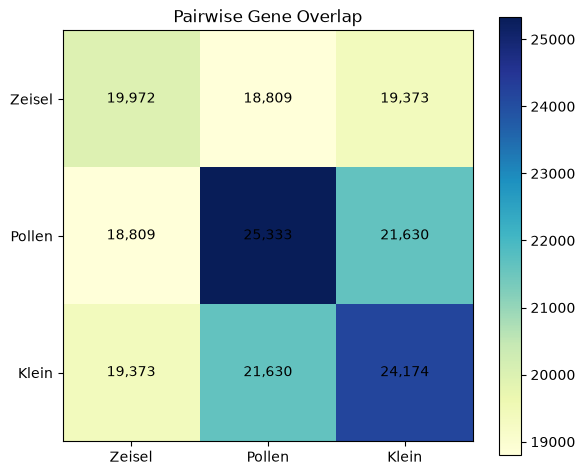


Using 18377 shared genes as the common feature space for all datasets.


In [25]:
# Visualize overlap as a heatmap
fig, ax = plt.subplots(figsize=(6, 5))
overlap_arr = overlap_matrix.values.astype(int)
im = ax.imshow(overlap_arr, cmap="YlGnBu")
ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names)
ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{overlap_arr[i,j]:,}", ha="center", va="center", fontsize=10)
ax.set_title("Pairwise Gene Overlap")
plt.colorbar(im)
plt.tight_layout()
plt.show()

print(f"\nUsing {len(shared_genes)} shared genes as the common feature space for all datasets.")


## 4. Shared Gene Space + Preprocessing

Subset all datasets to shared genes, normalize, and compute PCA in a common space. The PCA is fit on the training data and applied (transformed) to Klein.


In [26]:
# ============================================================
# Subset to shared genes, normalize, PCA
# ============================================================

shared_genes_sorted = sorted(shared_genes)
N_PCS = 50

# Subset each dataset to shared genes
def subset_and_normalize(adata, genes):
    """Subset to shared genes, normalize, log-transform."""
    sub = adata[:, adata.var_names.isin(genes)].copy()
    sub = sub[:, shared_genes_sorted].copy()
    sc.pp.filter_cells(sub, min_genes=10)
    sub.layers["counts"] = sub.X.copy()
    sc.pp.normalize_total(sub)
    sc.pp.log1p(sub)
    return sub

zeisel_sub = subset_and_normalize(zeisel_adata, shared_genes)
pollen_sub = subset_and_normalize(pollen_adata, shared_genes)
klein_sub = subset_and_normalize(klein_adata, shared_genes)

print("After subsetting to shared genes + normalization:")
for name, sub in [("Zeisel", zeisel_sub), ("Pollen", pollen_sub), ("Klein", klein_sub)]:
    print(f"  {name:8s}: {sub.n_obs} cells x {sub.n_vars} genes")

# Fit PCA on training data (Zeisel + Pollen combined)
train_X = np.vstack([zeisel_sub.X if not hasattr(zeisel_sub.X, 'toarray') else zeisel_sub.X.toarray(),
                     pollen_sub.X if not hasattr(pollen_sub.X, 'toarray') else pollen_sub.X.toarray()])
print(f"\nTraining PCA on combined train data: {train_X.shape}")

# Standardize before PCA
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)

pca = PCA(n_components=N_PCS, random_state=42)
pca.fit(train_X_scaled)
print(f"Variance explained by {N_PCS} PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Transform all datasets
def get_pca_embedding(adata):
    X = adata.X if not hasattr(adata.X, 'toarray') else adata.X.toarray()
    return pca.transform(scaler.transform(X))

zeisel_pca = get_pca_embedding(zeisel_sub)
pollen_pca = get_pca_embedding(pollen_sub)
klein_pca = get_pca_embedding(klein_sub)

print(f"\nPCA embeddings:")
print(f"  Zeisel: {zeisel_pca.shape}")
print(f"  Pollen: {pollen_pca.shape}")
print(f"  Klein:  {klein_pca.shape}")


After subsetting to shared genes + normalization:
  Zeisel  : 3005 cells x 18377 genes
  Pollen  : 863 cells x 18377 genes
  Klein   : 8669 cells x 18377 genes

Training PCA on combined train data: (3868, 18377)
Variance explained by 50 PCs: 24.3%

PCA embeddings:
  Zeisel: (3005, 50)
  Pollen: (863, 50)
  Klein:  (8669, 50)


## 5. GAT Training

Train the unsupervised GAT autoencoder on the combined training data (Zeisel + Pollen). The model learns to refine PCA embeddings by aggregating information from KNN neighbors.


In [27]:
# ============================================================
# GAT Autoencoder definition
# ============================================================

class GATAutoencoder(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, embed_dim, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=0.3)
        self.gat2 = GATConv(hidden_dim * heads, embed_dim, heads=1, dropout=0.3)
        self.decoder = torch.nn.Linear(embed_dim, in_dim)

    def encode(self, x, edge_index):
        h = F.elu(self.gat1(x, edge_index))
        h = F.dropout(h, p=0.3, training=self.training)
        h = self.gat2(h, edge_index)
        return h

    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        x_recon = self.decoder(z)
        return x_recon, z


def build_knn_graph(embeddings, k=15):
    knn = NearestNeighbors(n_neighbors=min(k, len(embeddings)-1), metric="euclidean")
    knn.fit(embeddings)
    _, indices = knn.kneighbors(embeddings)
    src, dst = [], []
    for i in range(len(embeddings)):
        for j in indices[i]:
            if i != j:
                src.append(i)
                dst.append(j)
    return torch.tensor([src, dst], dtype=torch.long)


print("GAT architecture defined.")


GAT architecture defined.


Combined training embeddings: (3868, 50)
Training graph: 3868 nodes, 54152 edges
  Epoch   0 | Loss: 158.5676
  Epoch  50 | Loss: 36.7120
  Epoch 100 | Loss: 28.1043
  Epoch 150 | Loss: 25.6883
  Epoch 200 | Loss: 25.4430
  Epoch 250 | Loss: 22.6978
  Epoch 299 | Loss: 23.3696


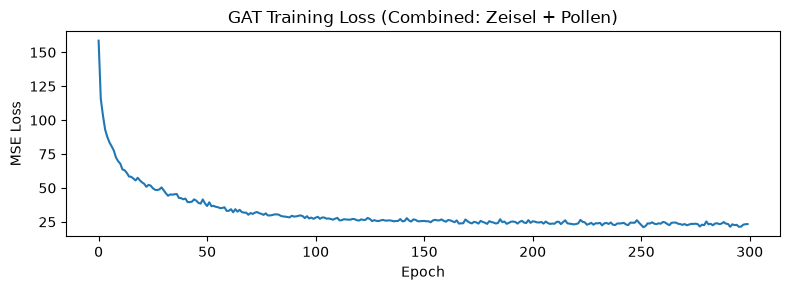


Training complete. Model has 23,506 parameters.


In [28]:
# ============================================================
# Train GAT on combined training data
# ============================================================

# Combine training PCA embeddings into one graph
train_pca_combined = np.vstack([zeisel_pca, pollen_pca])
print(f"Combined training embeddings: {train_pca_combined.shape}")

# Build KNN graph on combined training data
edge_index = build_knn_graph(train_pca_combined, k=15)
x_train = torch.tensor(np.ascontiguousarray(train_pca_combined), dtype=torch.float32)
print(f"Training graph: {x_train.shape[0]} nodes, {edge_index.shape[1]} edges")

# Init model
HIDDEN_DIM = 64
EMBED_DIM = 32
EPOCHS = 300
LR = 0.005

model = GATAutoencoder(in_dim=N_PCS, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, heads=4)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Train
model.train()
losses = []
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    x_recon, z = model(x_train, edge_index)
    loss = F.mse_loss(x_recon, x_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        print(f"  Epoch {epoch:3d} | Loss: {loss.item():.4f}")

# Plot training loss
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GAT Training Loss (Combined: Zeisel + Pollen)")
plt.tight_layout()
plt.show()

print(f"\nTraining complete. Model has {sum(p.numel() for p in model.parameters()):,} parameters.")


## 6. Transfer to Klein

Apply the frozen GAT weights to Klein's PCA embeddings. Build Klein's own KNN graph, run the trained encoder — no further training.


In [29]:
# ============================================================
# Apply trained GAT to Klein (frozen weights)
# ============================================================

# Build Klein's own KNN graph
klein_edge_index = build_knn_graph(klein_pca, k=15)
x_klein = torch.tensor(np.ascontiguousarray(klein_pca), dtype=torch.float32)
print(f"Klein graph: {x_klein.shape[0]} nodes, {klein_edge_index.shape[1]} edges")

# Run frozen encoder
model.eval()
with torch.no_grad():
    _, klein_gat_embeddings = model(x_klein, klein_edge_index)
    klein_gat_embeddings = klein_gat_embeddings.numpy()

print(f"Klein GAT embeddings (transferred): {klein_gat_embeddings.shape}")

# Also get training set embeddings for reference
with torch.no_grad():
    _, train_gat_embeddings = model(x_train, edge_index)
    train_gat_embeddings = train_gat_embeddings.numpy()

# Split back into individual training datasets
n_zeisel = len(zeisel_pca)
zeisel_gat = train_gat_embeddings[:n_zeisel]
pollen_gat = train_gat_embeddings[n_zeisel:]
print(f"Training embeddings: Zeisel={zeisel_gat.shape}, Pollen={pollen_gat.shape}")


Klein graph: 8669 nodes, 121366 edges
Klein GAT embeddings (transferred): (8669, 32)
Training embeddings: Zeisel=(3005, 32), Pollen=(863, 32)


## 7. Evaluation — Baselines + Comparison

Cluster Klein with KMeans (on raw PCA), SC3, and KMeans (on GAT-refined embeddings). Compare ARI against known cell stages.


In [30]:
# ============================================================
# Clustering on Klein — all methods
# ============================================================

true_klein = klein_sub.obs["cell_stage"] if "cell_stage" in klein_sub.obs else klein_adata.obs["cell_stage"]
k_values = [4, 8, 10]

# Attach PCA to AnnData so SC3 can find it
klein_sub.obsm["X_pca"] = np.ascontiguousarray(klein_pca)

# KMeans on raw PCA
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    klein_sub.obs[f"kmeans_k{k}"] = km.fit_predict(klein_pca).astype(str)

# KMeans on GAT embeddings (transferred)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    klein_sub.obs[f"gat_k{k}"] = km.fit_predict(klein_gat_embeddings).astype(str)

# SC3
print("Running SC3 on Klein...")
sc3s.tl.consensus(klein_sub, n_clusters=k_values)

# Results
print("\n--- Klein ARI Comparison (vs cell_stage) ---")
print(f"{'k':<4} {'KMeans (PCA)':<16} {'SC3':<16} {'GAT (Transfer)':<16}")
print("-" * 52)
for k in k_values:
    km_ari = adjusted_rand_score(true_klein, klein_sub.obs[f"kmeans_k{k}"])
    sc3_ari = adjusted_rand_score(true_klein, klein_sub.obs[f"sc3s_{k}"])
    gat_ari = adjusted_rand_score(true_klein, klein_sub.obs[f"gat_k{k}"])
    print(f"{k:<4} {km_ari:<16.4f} {sc3_ari:<16.4f} {gat_ari:<16.4f}")


INFO:root:multiplier_facility not set, using default value of 3...
INFO:root:number of facilities calculated as 30


Running SC3 on Klein...


INFO:root:original binary matrix shape: (8669, 20)
INFO:root:original binary matrix shape: (8669, 40)
INFO:root:original binary matrix shape: (8669, 50)



--- Klein ARI Comparison (vs cell_stage) ---
k    KMeans (PCA)     SC3              GAT (Transfer)  
----------------------------------------------------
4    0.2577           0.2513           0.2483          
8    0.1380           0.1010           0.1239          
10   0.0900           0.0506           0.1029          


In [31]:
# ============================================================
# Dropout robustness test on Klein
# ============================================================

dropout_rate = 0.15
np.random.seed(42)

# Inject dropouts into Klein's raw counts
klein_noisy = klein_sub.copy()
counts = klein_noisy.layers["counts"].copy()
non_zero = counts > 0
keep = np.random.binomial(1, 1 - dropout_rate, size=counts.shape).astype(bool)
counts[non_zero & ~keep] = 0
klein_noisy.X = counts

# Re-normalize + PCA in same shared space
sc.pp.normalize_total(klein_noisy)
sc.pp.log1p(klein_noisy)
X_noisy = klein_noisy.X if not hasattr(klein_noisy.X, 'toarray') else klein_noisy.X.toarray()
klein_noisy_pca = pca.transform(scaler.transform(X_noisy))

# KMeans on noisy PCA
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    klein_noisy.obs[f"kmeans_k{k}"] = km.fit_predict(klein_noisy_pca).astype(str)

# GAT transfer on noisy
klein_noisy_edge = build_knn_graph(klein_noisy_pca, k=15)
x_noisy = torch.tensor(np.ascontiguousarray(klein_noisy_pca), dtype=torch.float32)
with torch.no_grad():
    _, klein_noisy_gat = model(x_noisy, klein_noisy_edge)
    klein_noisy_gat = klein_noisy_gat.numpy()

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    klein_noisy.obs[f"gat_k{k}"] = km.fit_predict(klein_noisy_gat).astype(str)

# SC3 on noisy
klein_noisy.obsm["X_pca"] = np.ascontiguousarray(klein_noisy_pca)
sc3s.tl.consensus(klein_noisy, n_clusters=k_values)

# Final comparison
print("=" * 60)
print("KLEIN — Clean vs Noisy (15% dropout) ARI Comparison")
print("=" * 60)
print(f"\n{'k':<4} {'Method':<18} {'Clean':<10} {'Noisy':<10} {'Degradation':<12}")
print("-" * 54)
for k in k_values:
    for method, col in [("KMeans (PCA)", f"kmeans_k{k}"), ("SC3", f"sc3s_{k}"), ("GAT (Transfer)", f"gat_k{k}")]:
        clean_ari = adjusted_rand_score(true_klein, klein_sub.obs[col])
        noisy_ari = adjusted_rand_score(true_klein, klein_noisy.obs[col])
        deg = clean_ari - noisy_ari
        print(f"{k:<4} {method:<18} {clean_ari:<10.4f} {noisy_ari:<10.4f} {deg:+.4f}")
    print()


INFO:root:multiplier_facility not set, using default value of 3...
INFO:root:number of facilities calculated as 30
INFO:root:original binary matrix shape: (8669, 20)
INFO:root:original binary matrix shape: (8669, 40)
INFO:root:original binary matrix shape: (8669, 50)


KLEIN — Clean vs Noisy (15% dropout) ARI Comparison

k    Method             Clean      Noisy      Degradation 
------------------------------------------------------
4    KMeans (PCA)       0.2577     0.2569     +0.0008
4    SC3                0.2513     0.2462     +0.0051
4    GAT (Transfer)     0.2483     0.2482     +0.0001

8    KMeans (PCA)       0.1380     0.1108     +0.0272
8    SC3                0.1010     0.0956     +0.0053
8    GAT (Transfer)     0.1239     0.1273     -0.0034

10   KMeans (PCA)       0.0900     0.0842     +0.0058
10   SC3                0.0506     0.0602     -0.0096
10   GAT (Transfer)     0.1029     0.1068     -0.0039



In [32]:
# ============================================================
# Also validate GAT worked on training data (sanity check)
# ============================================================

# Zeisel clustering with GAT embeddings vs PCA
print("--- Training Set Validation (Zeisel, k=7) ---")
true_zeisel = zeisel_sub.obs["cell_type"]

km_pca = KMeans(n_clusters=7, random_state=42, n_init=10).fit_predict(zeisel_pca)
km_gat = KMeans(n_clusters=7, random_state=42, n_init=10).fit_predict(zeisel_gat)

print(f"  KMeans on PCA:  ARI = {adjusted_rand_score(true_zeisel, km_pca):.4f}")
print(f"  KMeans on GAT:  ARI = {adjusted_rand_score(true_zeisel, km_gat):.4f}")
print("\nIf GAT > PCA here, the model learned useful structure from the training data.")


--- Training Set Validation (Zeisel, k=7) ---
  KMeans on PCA:  ARI = 0.7895
  KMeans on GAT:  ARI = 0.7898

If GAT > PCA here, the model learned useful structure from the training data.
